In [4]:


# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from lattice import Lattice
import pyrochlore
import visual


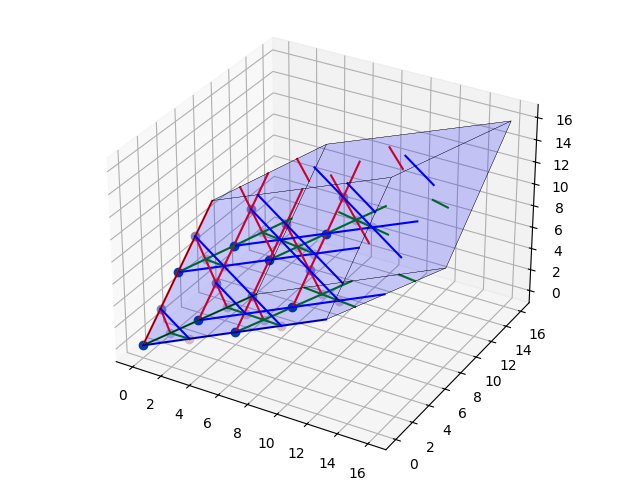

In [20]:
%matplotlib widget
plt.close('all')
# Build the lattice
spin_lat = Lattice(pyrochlore.primitive, [[2,0,0],[0,2,0],[0,0,2]])
# spin_lat = Lattice(pyrochlore.primitive, [[1,-1,-1],[-1,1,-1],[-1,-1,1] ])

fig =plt.figure()
ax=fig.add_axes([0,0,1,1],projection='3d')
visual.plot_cell(ax, spin_lat)

In [11]:
def lattice_curl(l:Lattice):
    curls = []
    for ring in pyrochlore.get_ringflips(l):
        curlA = 0
        mult = 1
        for idx in ring:
            curlA += mult * l.atoms[idx].gaugeA
            mult *= -1
        curls.append(curlA)
    return np.array(curls)
            

In [12]:
import itertools

def set_landau_gauge(alpha:np.ndarray, l:Lattice):
    alpha = np.array(alpha)
    assert np.allclose(np.exp(1.0j*np.array(l.periodicity) @ alpha),1.0), \
        "alpha is incompatible with unit cell size"
    for I in l.enumerate_primitives():
        a = I @ alpha
        for mu in range(4):
            J = l.linear_idx_from_tuple(I, mu)
            
            l.atoms[J].gaugeA = a[mu]
            
        

In [13]:
π=np.pi
set_landau_gauge([
    [0,0,0,0],
    [π,0,0,0],
    [0,π,0,0]
], spin_lat)

lattice_curl(spin_lat)

array([-3.14159265, -3.14159265,  3.14159265,  3.14159265,  3.14159265,
       -3.14159265, -3.14159265,  3.14159265, -3.14159265,  3.14159265,
        3.14159265, -3.14159265,  3.14159265,  3.14159265, -3.14159265,
       -3.14159265, -3.14159265, -3.14159265,  3.14159265,  3.14159265,
        3.14159265, -3.14159265, -3.14159265,  3.14159265, -3.14159265,
        3.14159265,  3.14159265, -3.14159265,  3.14159265,  3.14159265,
       -3.14159265, -3.14159265])

In [14]:
negated_spins = [i for i,s in enumerate(spin_lat.atoms) if abs(s.gaugeA) > 1e-5 ]


In [15]:
negated_bonds = [b for b in spin_lat.bonds 
                 if b['from_idx'] in negated_spins or b['to_idx'] in negated_spins]

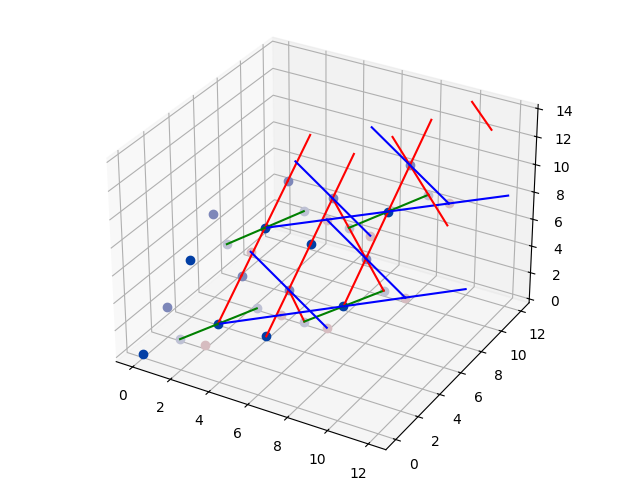

In [19]:
plt.close('all')
fig =plt.figure()
ax=fig.add_axes([0,0,1,1],projection='3d')
visual.plot_atoms(ax, spin_lat)
visual.plot_bonds(ax, spin_lat, negated_bonds)